# USB 카메라 표지판 검출

학습한 YOLO로 화면 전체에서 제한속도 표지판의 위치를 찾습니다. **숫자(30·50 등)는 읽지 않습니다.**

로컬 Windows VS Code/Jupyter에서 실행하세요. 기존 `00_오후_실습준비.ipynb`를 같은 폴더에 둡니다. 카메라는 실행 옵션을 켰을 때만 열립니다.

In [6]:
CONFIG = {'period': 'pm', 'payload_sha256': '1b2d65c48c7ece0ab63a985fca4bb38743f77497cfba30fe176261d279497c47', 'preparation_name': '00_오후_실습준비.ipynb'}

# 제공 코드: 현재 노트북 커널에 패키지를 설치하고 수업 자료를 준비합니다.
from pathlib import Path
import os, sys, json, hashlib, base64, io, zipfile, subprocess, importlib.metadata

if sys.version_info[:2] not in [(3, 11), (3, 12)]:
    raise RuntimeError('Python 3.11 또는 3.12 커널을 선택한 뒤 이 셀을 다시 실행하세요.')

def _ngv_sha(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as f:
        for block in iter(lambda: f.read(1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

_wanted = {'torch':'2.6.0', 'torchvision':'0.21.0', 'numpy':'1.26.4',
           'Pillow':'12.3.0', 'matplotlib':'3.11.2', 'opencv-python':'4.11.0.86'}
if CONFIG['period'] == 'pm':
    _wanted['ultralytics'] = '8.3.221'
_missing = []
for _pkg, _version in _wanted.items():
    try:
        _installed = importlib.metadata.version(_pkg).split('+')[0]
    except importlib.metadata.PackageNotFoundError:
        _installed = None
    if _installed != _version:
        _missing.append(_pkg)
if _missing:
    _modules = {'torch':'torch','torchvision':'torchvision','numpy':'numpy',
                'Pillow':'PIL','matplotlib':'matplotlib','opencv-python':'cv2','ultralytics':'ultralytics'}
    _restart = any(_modules[p] in sys.modules for p in _missing)
    print('현재 커널에 필요한 패키지를 설치합니다. 처음에는 인터넷 연결이 필요합니다.', flush=True)
    if any(p in _missing for p in ['torch','torchvision']):
        subprocess.check_call([sys.executable,'-m','pip','install','torch==2.6.0','torchvision==0.21.0',
                               '--index-url','https://download.pytorch.org/whl/cpu'])
    _others = [p+'=='+_wanted[p] for p in _missing if p not in ['torch','torchvision']]
    if _others:
        subprocess.check_call([sys.executable,'-m','pip','install',*_others])
    if _restart:
        raise RuntimeError('설치가 끝났습니다. 커널을 다시 시작한 뒤 첫 셀부터 실행하세요.')

_cache_base = Path(os.environ.get('NGV_DAY4_CACHE', str(Path.home()/'.ngv_day4_2026'))).expanduser().resolve()
ROOT = _cache_base/CONFIG['period']/CONFIG['payload_sha256'][:12]
ROOT.mkdir(parents=True, exist_ok=True)
_receipt = ROOT/'prepared.json'

def _ngv_resources_ok():
    if not _receipt.exists():
        return False
    try:
        saved = json.loads(_receipt.read_text(encoding='utf-8'))
        return saved['payload_sha256'] == CONFIG['payload_sha256'] and all(
            (ROOT/name).is_file() and _ngv_sha(ROOT/name) == digest
            for name, digest in saved['files'].items())
    except (OSError, ValueError, KeyError):
        return False

def _ngv_find_preparation():
    # VS Code/Jupyter의 작업 폴더 및 하위 4단계에서 준비 노트북을 찾습니다.
    # 특정 '최종본' 폴더명에 의존하지 않습니다.
    roots = [Path.cwd(), Path.cwd().parent]
    visited = set()
    for start in roots:
        count = 0
        for folder, dirs, files in os.walk(start):
            here = Path(folder)
            if here in visited:
                dirs[:] = []
                continue
            visited.add(here)
            count += 1
            depth = len(here.relative_to(start).parts)
            dirs[:] = [d for d in dirs if not d.startswith('.') and d not in
                       {'node_modules','__pycache__','data','dataset_group20_seed42','raw','models','runs'}]
            if depth >= 4 or count > 1500:
                dirs[:] = []
            if CONFIG['preparation_name'] in files:
                candidate = here/CONFIG['preparation_name']
                try:
                    notebook = json.loads(candidate.read_text(encoding='utf-8'))
                    resource = notebook['metadata']['ngv_resource']
                    if resource['payload_sha256'] == CONFIG['payload_sha256']:
                        return resource
                except (OSError, ValueError, KeyError):
                    continue
    raise FileNotFoundError('준비 노트북을 찾지 못했습니다. 받은 파일을 모두 압축 해제하고 '
                            +CONFIG['preparation_name']+'을 열어 첫 셀을 실행하세요. '
                            'Jupyter를 다른 위치에서 열었다면 준비 노트북이 있는 폴더를 작업 폴더로 선택하세요.')

if not _ngv_resources_ok():
    print('준비 노트북에 포함된 수업 자료를 확인합니다.', flush=True)
    _resource = _ngv_find_preparation()
    _bytes = base64.b64decode(_resource['payload_base64'], validate=True)
    if hashlib.sha256(_bytes).hexdigest() != CONFIG['payload_sha256']:
        raise ValueError('준비 노트북의 자료가 손상됐습니다. 원본 준비 노트북을 다시 받으세요.')
    with zipfile.ZipFile(io.BytesIO(_bytes)) as _zip:
        _manifest = json.loads(_zip.read('manifest.json'))
        for _name, _digest in _manifest.items():
            _target = (ROOT/_name).resolve()
            if not _target.is_relative_to(ROOT) or _target == ROOT:
                raise ValueError('자료 경로가 올바르지 않습니다.')
            _content = _zip.read(_name)
            if hashlib.sha256(_content).hexdigest() != _digest:
                raise ValueError('자료 무결성 오류: '+_name)
            _target.parent.mkdir(parents=True, exist_ok=True)
            _temp = _target.with_name(_target.name+'.preparing')
            _temp.write_bytes(_content)
            _temp.replace(_target)
    _receipt.write_text(json.dumps({'payload_sha256':CONFIG['payload_sha256'],'files':_manifest}),encoding='utf-8')
    del _resource, _bytes

os.environ['MPLCONFIGDIR'] = str(ROOT/'.runtime/matplotlib')
os.environ['YOLO_CONFIG_DIR'] = str(ROOT/'.runtime/yolo')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True,exist_ok=True)
Path(os.environ['YOLO_CONFIG_DIR']).mkdir(parents=True,exist_ok=True)
sys.path.insert(0,str(ROOT)) if str(ROOT) not in sys.path else None
# 다른 실습 폴더에서 이미 불러온 같은 이름의 모듈은 이 자료의 모듈로 교체합니다.
_module_name = 'signlab' if CONFIG['period']=='am' else 'speed_project'
_old_module = sys.modules.get(_module_name)
if _old_module is not None and Path(_old_module.__file__).resolve().parent != ROOT:
    del sys.modules[_module_name]

if CONFIG['period']=='pm':
    import speed_project as _ngv_project
    import shutil
    _dataset = ROOT/'dataset_group20_seed42'
    _records = json.loads((_dataset/'annotations.json').read_text(encoding='utf-8'))
    _images_ready = all((_dataset/'images'/r['split']/name).is_file() and
                        _ngv_sha(_dataset/'images'/r['split']/name)==r['sha256']
                        for name,r in _records.items())
    if not _images_ready:
        print('오후 원본 사진을 공개 배포처에서 내려받습니다(약 229 MB, 최초 1회).',flush=True)
        print('출처: https://www.kaggle.com/datasets/andrewmvd/road-sign-detection',flush=True)
        _ngv_project.download_data()
        for _name,_record in _records.items():
            _source = ROOT/'raw/images'/_name
            if not _source.is_file() or _ngv_sha(_source)!=_record['sha256']:
                raise ValueError('원본 사진 확인 실패: '+_name)
            _target = _dataset/'images'/_record['split']/_name
            _target.parent.mkdir(parents=True,exist_ok=True)
            if not _target.exists():
                try:
                    os.link(_source,_target)
                except OSError:
                    shutil.copy2(_source,_target)
            elif _ngv_sha(_target)!=_record['sha256']:
                shutil.copy2(_source,_target)
    _ngv_project.prepare_data()
print('준비 완료. 다음 실습 셀을 실행하세요.\n자료·학습 결과 저장 위치:',ROOT,flush=True)




준비 완료. 다음 실습 셀을 실행하세요.
자료·학습 결과 저장 위치: C:\Users\User\.ngv_day4_2026\pm\1b2d65c48c7e


In [7]:
from pathlib import Path
import time, os
os.environ['MPLCONFIGDIR']=str(ROOT/'.runtime/matplotlib')
os.environ['YOLO_CONFIG_DIR']=str(ROOT/'.runtime/yolo')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True,exist_ok=True)
Path(os.environ['YOLO_CONFIG_DIR']).mkdir(parents=True,exist_ok=True)
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO
torch.set_num_threads(4)
plt.rcParams['font.family']='Malgun Gothic'

# 04에서 비교한 20 epoch 모델. 직접 학습한 모델을 쓰려면 이 경로만 바꾸세요.
WEIGHTS = ROOT/'runs/verified/checkpoints/epoch20.pt'
assert WEIGHTS.is_file(), f'모델 파일이 없습니다: {WEIGHTS}'
detector = YOLO(str(WEIGHTS))
assert detector.names == {0: 'speedlimit'}, detector.names
print('사용 모델:', WEIGHTS)
print('검출 대상:', detector.names)


사용 모델: C:\Users\User\.ngv_day4_2026\pm\1b2d65c48c7e\runs\verified\checkpoints\epoch20.pt
검출 대상: {0: 'speedlimit'}


## 1. 실행 설정
점수 기준과 입력 해상도는 03·04에서 비교한 값으로 바꿀 수 있습니다.

In [8]:
CAMERA_INDEX = 0       # 내장 카메라가 열리면 1, 2로 바꾸세요.
CONF = 0.40            # 검출 점수 기준
IMGSZ = 320            # 160 / 320 / 640
NMS_IOU = 0.70         # 중복 제거 기준. 정답 평가 IoU와 다릅니다.
MAX_SECONDS = None    # 시간 제한 없음. 60을 넣으면 60초 후 종료
assert 0 <= CONF <= 1 and 0 <= NMS_IOU <= 1
assert IMGSZ in (160,320,640) and (MAX_SECONDS is None or MAX_SECONDS > 0)


## 2. 프레임 검출 · 제공 코드
전체 BGR 프레임을 입력하면 YOLO가 크기 조절과 전처리를 수행합니다. 화면 점수는 예측 신뢰도이며 정확도가 아닙니다.

In [9]:
def detect_frame(frame, conf=None, imgsz=None):
    conf = CONF if conf is None else conf
    imgsz = IMGSZ if imgsz is None else imgsz
    # OpenCV의 BGR 배열을 그대로 전달합니다. RGB 변환이나 48×48 축소는 하지 않습니다.
    start = time.perf_counter()
    result = detector.predict(source=frame, device='cpu', imgsz=imgsz,
                              conf=conf, iou=NMS_IOU, verbose=False)[0]
    elapsed_ms = (time.perf_counter()-start)*1000
    shown = frame.copy()
    for box, score in zip(result.boxes.xyxy.cpu().numpy(), result.boxes.conf.cpu().numpy()):
        x1,y1,x2,y2 = map(int,box)
        cv2.rectangle(shown,(x1,y1),(x2,y2),(0,255,0),2)
        cv2.putText(shown,f'speedlimit {score:.1%}',(x1,max(20,y1-8)),
                    cv2.FONT_HERSHEY_SIMPLEX,.6,(0,255,0),2)
    return shown, result, elapsed_ms


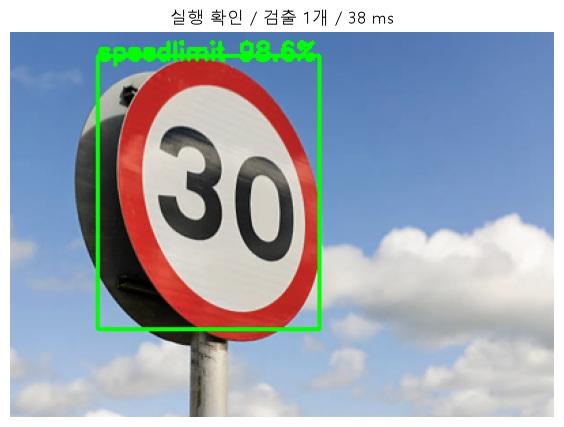

In [10]:
# 카메라 연결 전에 공개 데이터 이미지로 모델 실행 확인
paths = sorted((ROOT/'dataset_group20_seed42/images/val').glob('*.png'))
assert paths, '준비 노트북을 먼저 실행하세요.'
frame = cv2.imread(str(paths[0]))
assert frame is not None
_ = detect_frame(frame)  # 최초 준비 시간 제외
shown, result, ms = detect_frame(frame)
plt.figure(figsize=(9,5)); plt.imshow(cv2.cvtColor(shown,cv2.COLOR_BGR2RGB))
plt.axis('off'); plt.title(f'실행 확인 / 검출 {len(result.boxes)}개 / {ms:.0f} ms'); plt.show()


## 3. USB 카메라
제한속도 표지판 사진을 다른 화면이나 인쇄물로 보여 주세요. 화면 반사·거리·각도에 따라 검출이 달라질 수 있습니다. 표시 창을 클릭한 뒤 **S**로 현재 장면을 보관하고 **Q/Esc**로 종료합니다. 왼쪽은 실시간 원본, 오른쪽은 최근 추론 결과입니다. CPU 추론 중에도 원본 화면이 갱신됩니다. 오전 카메라는 먼저 종료하세요.

In [11]:
# 이 셀에서 실행 여부를 바꾸세요. 오전 카메라는 Q/Esc로 먼저 종료하세요.
RUN_CAMERA = False        # True로 바꾼 뒤 이 셀 실행
PREVIEW_ONLY = False      # True: YOLO 없이 카메라 연결만 확인
# 왼쪽: 실시간 원본 / 오른쪽: 가장 최근 추론을 완료한 프레임
# S: 현재 원본 보관 / Q 또는 Esc: 종료. 원본과 검출 화면에는 시간차가 있습니다.
from concurrent.futures import ThreadPoolExecutor
captured_frame = None
if RUN_CAMERA:
    cap = None
    worker = None
    pending = None
    window = 'YOLO USB | LIVE left / DETECTION right | S capture | Q quit'
    try:
        print(f'카메라 {CAMERA_INDEX} 연결 중...', flush=True)
        cap = cv2.VideoCapture(CAMERA_INDEX)
        if not cap.isOpened():
            cap.release()
            cap = cv2.VideoCapture(CAMERA_INDEX, cv2.CAP_DSHOW)
        if not cap.isOpened():
            raise RuntimeError('카메라 연결 실패: 오전 카메라를 종료하고 같은 CAMERA_INDEX를 사용하세요.')
        ok, frame = cap.read()
        if not ok:
            raise RuntimeError('장치는 열렸지만 영상이 없습니다. 오전 노트북/카메라 앱을 종료한 뒤 다시 실행하세요.')
        cv2.namedWindow(window, cv2.WINDOW_NORMAL)
        print('연결 성공. 표시 창에서 Q/Esc로 종료합니다.', flush=True)
        if not PREVIEW_ONLY: worker = ThreadPoolExecutor(max_workers=1)
        last_detection = None
        last_ms = None
        started = time.perf_counter()
        while True:
            if MAX_SECONDS is not None and time.perf_counter()-started >= MAX_SECONDS: break
            if pending is not None and pending.done():
                last_detection, result, last_ms = pending.result()
                pending = None
            if not PREVIEW_ONLY and pending is None:
                # 한 번에 한 프레임만 추론. 기다리는 프레임을 쌓지 않습니다.
                pending = worker.submit(detect_frame, frame.copy(), CONF, IMGSZ)
            live = cv2.resize(frame, (640,480))
            cv2.putText(live,'LIVE | S: capture | Q: quit',(10,25),cv2.FONT_HERSHEY_SIMPLEX,.6,(0,255,255),2)
            if PREVIEW_ONLY:
                shown = live
            else:
                right = np.zeros_like(live) if last_detection is None else cv2.resize(last_detection,(640,480))
                status = 'YOLO warming up...' if last_ms is None else f'LAST RESULT {last_ms:.0f} ms | conf={CONF} size={IMGSZ}'
                cv2.putText(right,status,(10,25),cv2.FONT_HERSHEY_SIMPLEX,.5,(0,255,255),2)
                shown = np.hstack([live,right])
            cv2.imshow(window,shown)
            key = cv2.waitKey(1) & 0xFF
            if key in (ord('s'),ord('S')):
                captured_frame = frame.copy()
                print('현재 원본을 보관했습니다.')
            if key in (ord('q'),ord('Q'),27): break
            try:
                if cv2.getWindowProperty(window,cv2.WND_PROP_VISIBLE)==0: break
            except cv2.error: pass
            ok,frame = cap.read()
            if not ok: raise RuntimeError('영상 수신이 중단됐습니다. USB 연결을 확인하세요.')
    except KeyboardInterrupt:
        print('카메라 실행을 중단했습니다.')
    finally:
        if cap is not None: cap.release()
        cv2.destroyAllWindows()
        if worker is not None:
            print('남은 추론을 정리합니다...', flush=True)
            worker.shutdown(wait=True, cancel_futures=True)
        print('카메라 해제 완료.')
else:
    print('이 셀의 RUN_CAMERA=True로 변경 후 실행하세요. 연결만 확인하려면 PREVIEW_ONLY=True도 설정하세요.')


이 셀의 RUN_CAMERA=True로 변경 후 실행하세요. 연결만 확인하려면 PREVIEW_ONLY=True도 설정하세요.


## 4. 같은 프레임에서 비교
위에서 보관한 프레임을 사용합니다. `trials`의 점수 기준·해상도를 조절하세요. 표지판을 놓쳤는지, 배경에 잘못된 박스가 생겼는지 확인합니다. 정답 박스가 없으므로 여기서는 AP·F1을 계산하지 않습니다. 시간은 단일 실행 참고값입니다.

In [12]:
if captured_frame is None:
    print('카메라 창에서 S를 눌러 프레임을 보관한 뒤 실행하세요.')
else:
    # 같은 원본 프레임에서 한 조건만 변경합니다. 첫 실행은 준비용입니다.
    trials = [('기준',CONF,IMGSZ),('점수 기준 변경',0.15,IMGSZ),('해상도 변경',CONF,640)]
    fig, axes = plt.subplots(1,3,figsize=(15,5))
    for ax,(name,conf,size) in zip(axes,trials):
        _ = detect_frame(captured_frame,conf,size)
        shown,result,ms = detect_frame(captured_frame,conf,size)
        ax.imshow(cv2.cvtColor(shown,cv2.COLOR_BGR2RGB)); ax.axis('off')
        ax.set_title(f'{name} / conf={conf} / 크기={size}\n검출 {len(result.boxes)}개 / {ms:.0f} ms')
        print(name, '점수:', [round(float(s),3) for s in result.boxes.conf])
    plt.tight_layout(); plt.show()


카메라 창에서 S를 눌러 프레임을 보관한 뒤 실행하세요.
